# Physics-Informed Neural Networks for the Schrödinger Equation

This notebook demonstrates how to solve the one-dimensional time-dependent Schrödinger equation with a harmonic potential using a Physics-Informed Neural Network (PINN).

The solution approach involves: 
- Generating synthetic reference data using a finite difference method
- Defining the Schrödinger PDE and boundary conditions
- Constructing a PINN architecture using DeepXDE
- Training with both PDE residual and data constraints
- Evaluating the neural network's accuracy against a reference solution

**Note:** The solution here uses a synthetic data loss generated from numerical solutions (not real experimental data).



In [35]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from scipy.interpolate import interp1d
import deepxde as dde
import torch

# Set default device to GPU if available
if torch.cuda.is_available():
    dde.config.set_default_device("gpu")


## Generate Synthetic Reference Data

We generate synthetic reference data by numerically solving the time-dependent Schrödinger equation using a finite difference method. 

This function constructs the Hamiltonian for a harmonic oscillator, evolves the wavefunction with a Gaussian initial condition, and samples the solution at randomly chosen \(x, t\) pairs. The resulting data will serve as 'measurement points' for the data loss in the PINN.

**Schrödinger equation is** 

$$
i\frac{\partial \psi}{\partial t}
=
-\frac{1}{2}\frac{\partial^2\psi}{\partial x^2}
+
V(x)\psi
$$


* Using Harmonic potential we have 


$$
i\frac{\partial \psi}{\partial t}
=
-\frac{1}{2}\frac{\partial^2\psi}{\partial x^2}
+
\frac{1}{2}x^2\psi
$$


* With Hamiltonian operator which is $$ H = -\frac{1}{2}\frac{\partial}{\partial x^2} + V(x)$$


* Leads us to define H with L which is the Laplace operator for finite-difference method represented by matrix. So instead of $\frac{\partial}{\partial x^2}$ we use 


$$
L=
\frac{1}{(dx)^2}
\begin{bmatrix}
-2 & 1 & 0 & \cdots \\
1 & -2 & 1 & \cdots \\
0 & 1 & -2 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$


* Which comes from
$$
\psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots 
\end{bmatrix}
$$

$$
\psi_{xx} = \frac{\psi_{i+1} + 2\psi_{i} + \psi_{i-1} }{(dx)^2}
$$


* So 
$$ H = -\frac{1}{2} L + V(x)  $$
$$i \psi_t = H\psi$$

* Then with our initial condition which is Gaussian: $\psi_0 = e^{-x^2}$ 

* Finally our equation becomes: 
$$\psi_{t} = e^{-iHt}\psi_0$$


In [ ]:
def generate_reference_data(num_samples=500, num_x=200, x_min=-5.0, x_max=5.0, t_min=0.0, t_max=1.0):
    """Generate synthetic Schrödinger solution data using a finite difference Hamiltonian.

    This function constructs a discretized Hamiltonian matrix for the harmonic oscillator,
    evolves the wavefunction using the matrix exponential, and collects random sample points.

    Parameters:
        num_samples (int): number of random sample points to generate.
        num_x (int): number of discretization points for x-grid.
        x_min, x_max (float): domain boundaries for x.
        t_min, t_max (float): time range for t.

    Returns:
        X_data (np.ndarray): random (x, t) points, shape (num_samples, 2).
        u_data (np.ndarray): real part of ψ at sample points, shape (num_samples, 1).
        v_data (np.ndarray): imaginary part of ψ at sample points, shape (num_samples, 1).
    """
    # Construct x-grid and finite-difference Laplacian matrix
    x_grid = np.linspace(x_min, x_max, num_x) #discrete points 
    dx = x_grid[1] - x_grid[0] #dx
    
    
    #defining an operator to calculate the the second derivative of psi
    main_diag = -2.0 * np.ones(num_x, dtype=np.complex128)
    off_diag = np.ones(num_x - 1, dtype=np.complex128)
    L = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(num_x, num_x)) / dx**2

    # Harmonic potential
    V = 0.5 * x_grid**2  # potential equation 

    H = -0.5 * L + diags(V, 0)  # Hamiltonian 

    # Initial wavefunction: Gaussian e^{-x^2}
    psi0 = np.exp(-x_grid**2).astype(np.complex128)

    # Cache solutions at different times to reuse if duplicate times appear
    psi_cache = {}

    # Collect random sample points
    xs = np.random.uniform(x_min, x_max, size=num_samples)
    ts = np.random.uniform(t_min, t_max, size=num_samples)

    u_data = np.zeros((num_samples, 1))
    v_data = np.zeros((num_samples, 1))

    for i, (xq, tq) in enumerate(zip(xs, ts)):
        # Compute solution ψ(x,t) if not already cached
        if tq not in psi_cache:
            psi_cache[tq] = expm_multiply((-1j) * H * tq, psi0)

        psi_at_t = psi_cache[tq]
        # For xq that is not in our grid we used cubic interpolation based on id they are imaginary or real
        u_interp = interp1d(x_grid, psi_at_t.real, kind="cubic", fill_value="extrapolate")
        v_interp = interp1d(x_grid, psi_at_t.imag, kind="cubic", fill_value="extrapolate")

        u_data[i, 0] = u_interp(xq)
        v_data[i, 0] = v_interp(xq)

    X_data = np.column_stack((xs, ts))
    return X_data, u_data, v_data


## PDE Definition and Domain Setup

We formulate the Schrödinger equation in real and imaginary parts. The neural network approximates \(u(x,t)\) (real part) and \(v(x,t)\) (imaginary part). Automatic differentiation is used to compute derivatives.

We also define the spatial domain \([-5, 5]\) and time domain \([0, 1]\), and we specify Dirichlet boundary conditions (zero at the boundaries) and the initial condition (Gaussian).


$$
i\frac{\partial \psi}{\partial t}
=
-\frac{1}{2}\frac{\partial^2\psi}{\partial x^2}
+
V(x)\psi
$$

Let $\psi = u + iv$ then
Then:

$$
\psi_t = u_t + i v_t
$$

$$
\psi_{xx} = u_{xx} + i v_{xx}
$$

Substitute:

$$
i(u_t + i v_t)
=
-\frac{1}{2}(u_{xx} + i v_{xx})
+
V(u + i v).
$$

Left side:

$$
i u_t - v_t.
$$

Right side:

$$
-\frac{1}{2}u_{xx}
-
\frac{i}{2}v_{xx}
+
Vu
+
iVv.
$$

Now compare real and imaginary parts.

Real part:

$$
-v_t
=
-\frac{1}{2}u_{xx}
+
Vu
$$

Move everything to one side:

$$
v_t
-
\frac{1}{2}u_{xx}
+
Vu
=
0.
$$
which is eq_v in code
Imaginary part:
$$u_t = -\frac{1}{2}v_{xx} + Vv$$
move everythingto the one side:
$$
u_t + \frac{1}{2} - Vv = 0
$$
which is eq_u in code 

In [ ]:
# Define the Schrödinger PDE residual in terms of u and v
def schrodinger_pde(x, y):

    # x contains input points (x,t)
    # y contains network outputs (u,v)
    u = y[:, 0:1] # real
    v = y[:, 1:2] # imaginary

    # First derivatives with respect to x (index 0) and t (index 1)
    u_t = dde.grad.jacobian(y, x, i=0, j=1)
    v_t = dde.grad.jacobian(y, x, i=1, j=1)

    # Second derivatives with respect to x for u and v
    u_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    v_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)

    # Harmonic potential V = 1/2 x^2
    V = 0.5 * x[:, 0:1] ** 2

    eq_u = u_t + 0.5 * v_xx - V * v
    eq_v = v_t - 0.5 * u_xx + V * u

    return [eq_u, eq_v]

# Domain boundaries
x_min, x_max = -5.0, 5.0
t_min, t_max = 0.0, 1.0

geom = dde.geometry.Interval(x_min, x_max)
timedomain = dde.geometry.TimeDomain(t_min, t_max)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# Initial conditions: psi(x,0) = e^{-x^2}
def initial_u(x):
    return np.exp(-x[:, 0:1] ** 2)

def initial_v(x):
    return np.zeros((len(x), 1))

# Dirichlet boundary conditions: u = v = 0 at x = ±5
# bc_u for real part; bc_v for imaginary part
bc_u = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary, component=0)
bc_v = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary, component=1)

# Initial condition constraints
ic_u = dde.icbc.IC(geomtime, initial_u, lambda x, on_initial: on_initial, component=0)
ic_v = dde.icbc.IC(geomtime, initial_v, lambda x, on_initial: on_initial, component=1)


## Create Data Loss Using Reference Solution

We generate synthetic reference data using the function defined above and include those data points in the training loss. 

`PointSetBC` enforces the neural network outputs to match the generated reference solution at specific random \((x,t)\) points for both the real and imaginary parts.


We also set a large number of collocation points for the PDE residual to ensure the network learns the physics across the domain.


In [4]:
# Generate synthetic data
X_data, u_data, v_data = generate_reference_data(num_samples=500, num_x=200)

# PointSetBC for matching the synthetic data (acts as 'measurement points')
data_bc_u = dde.icbc.PointSetBC(X_data, u_data, component=0)
data_bc_v = dde.icbc.PointSetBC(X_data, v_data, component=1)

# Create the PINN training data with PDE residual, boundary, initial, and data constraints
data = dde.data.TimePDE(
    geomtime,
    schrodinger_pde,
    [bc_u, bc_v, ic_u, ic_v, data_bc_u, data_bc_v],
    num_domain=2000,
    num_boundary=50,
    num_initial=100,
    train_distribution="pseudo",
)


## Define the Neural Network Architecture

We use a fully-connected neural network (FNN) with several hidden layers to approximate the solution. 

The network takes inputs \((x,t)\) and outputs two values: \(u\) (real part) and \(v\) (imaginary part).

We use the hyperbolic tangent activation function ('tanh') and the Glorot normal initializer for weights.


In [6]:
# Define the neural network
# Layer sizes: input layer (2), four hidden layers (64 neurons each), and output layer (2)
layer_sizes = [2] + [64] * 4 + [2]

net = dde.nn.FNN(layer_sizes,"tanh","Glorot normal")

model = dde.Model(data, net)


## Training the PINN

We train the model using a two-stage approach:
1. **Adam optimizer** for a fixed number of iterations. Adam is a first-order optimization algorithm that quickly reduces the loss to a reasonable neighborhood.
2. **L-BFGS optimizer** (a quasi-Newton method) to refine the solution further.

Note: Training with the PDE and data constraints can be computationally intensive, so you may adjust the number of iterations depending on your environment.


In [8]:
# Train with Adam
model.compile(optimizer="adam", lr=1e-3)
losshistory, train_state = model.train(iterations=1000, display_every=1000)

# Switch to L-BFGS for finer optimization
model.compile(optimizer="L-BFGS")
losshistory, train_state = model.train()


Compiling model...
'compile' took 0.000925 s

Training model...

215       [5.44e-03, 1.34e-02, 2.11e-04, 4.26e-05, 2.65e-02, 1.27e-03, 1.98e-02, 1.12e-02]    [5.44e-03, 1.34e-02, 2.11e-04, 4.26e-05, 2.65e-02, 1.27e-03, 1.98e-02, 1.12e-02]    []  
1000      [7.09e-04, 1.80e-03, 9.22e-06, 4.45e-06, 2.71e-03, 1.16e-04, 1.90e-03, 2.87e-03]    [7.09e-04, 1.80e-03, 9.22e-06, 4.45e-06, 2.71e-03, 1.16e-04, 1.90e-03, 2.87e-03]    []  
1215      [6.52e-04, 1.56e-03, 1.04e-05, 3.96e-06, 1.79e-03, 1.02e-04, 1.36e-03, 1.93e-03]    [6.52e-04, 1.56e-03, 1.04e-05, 3.96e-06, 1.79e-03, 1.02e-04, 1.36e-03, 1.93e-03]    []  

Best model at step 1215:
  train loss: 7.40e-03
  test loss: 7.40e-03
  test metric: []

'train' took 89.327863 s

Compiling model...
'compile' took 0.000391 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
1215      [6.52

## Evaluate the Model

After training, we evaluate the neural network on a structured grid of \((x,t)\) points and compare its predictions with a high-accuracy reference solution generated on the same grid.

The relative \(L_2\) error quantifies the agreement between the PINN and the reference solution.


In [9]:
# Generate a structured test grid
x_test = np.linspace(x_min, x_max, 101)
t_test = np.linspace(t_min, t_max, 51)
X_test, T_test = np.meshgrid(x_test, t_test)

XT_test = np.hstack((X_test.flatten()[:, None], T_test.flatten()[:, None]))

# Predict with the trained model
y_pred = model.predict(XT_test)

# Compute reference solution on the test grid

def reference_solution_at_points(X_query, x_min=x_min, x_max=x_max, num_x=201):
    """Compute the reference solution (real and imaginary parts) on given (x,t) points.

    This function uses the finite difference Hamiltonian to compute the solution at specified times,
    and performs cubic interpolation to evaluate at each x-coordinate.
    """
    x_grid = np.linspace(x_min, x_max, num_x)
    dx = x_grid[1] - x_grid[0]

    main_diag = -2.0 * np.ones(num_x, dtype=np.complex128)
    off_diag = np.ones(num_x - 1, dtype=np.complex128)
    L = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(num_x, num_x)) / dx**2

    V = 0.5 * x_grid**2
    H = -0.5 * L + diags(V, 0)

    psi0 = np.exp(-x_grid**2).astype(np.complex128)

    y_true = np.zeros((len(X_query), 2))

    unique_times = np.unique(X_query[:, 1])
    psi_cache = {}

    for t0 in unique_times:
        # Solve if not cached
        if t0 not in psi_cache:
            psi_cache[t0] = expm_multiply((-1j) * H * t0, psi0)

        psi_t = psi_cache[t0]

        # Interpolators for real and imaginary parts
        real_interp = interp1d(x_grid, psi_t.real, kind="cubic")
        imag_interp = interp1d(x_grid, psi_t.imag, kind="cubic")

        mask = np.isclose(X_query[:, 1], t0)
        y_true[mask, 0] = real_interp(X_query[mask, 0])
        y_true[mask, 1] = imag_interp(X_query[mask, 0])

    return y_true

y_true = reference_solution_at_points(XT_test)

# Compute relative L2 error
error = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
print("Relative L2 error of PINN:", error)


Relative L2 error of PINN: 0.0014083349586537092


## Visualize the Learned Solution

Finally, we can visualize the probability density \(|\psi(x,t)|^2\) (real and imaginary parts squared sum) on a 2D grid, along with time slices and a 3D surface plot. This helps us inspect how the wave packet evolves in time.


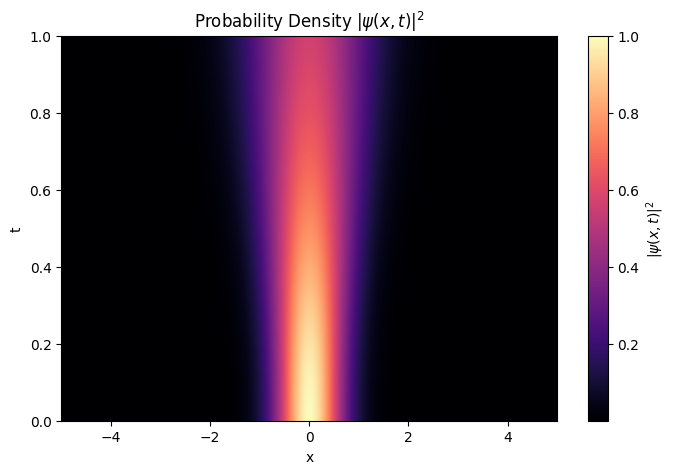

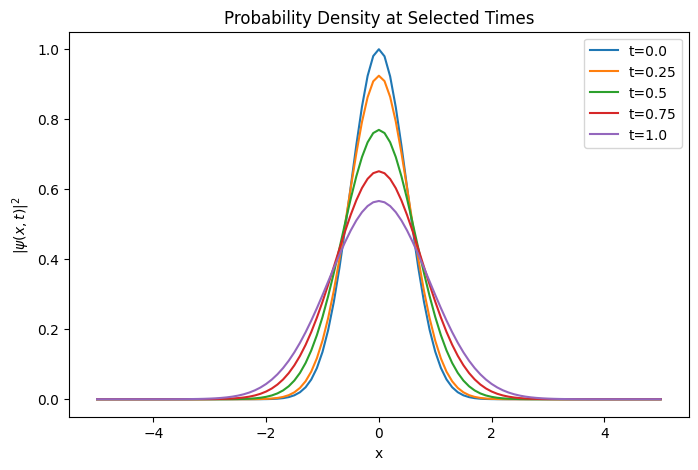

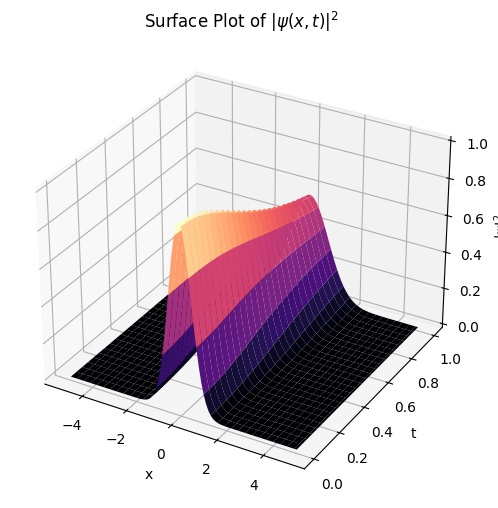

In [10]:
# Compute probability density on the test grid
u_pred = y_pred[:, 0].reshape(len(t_test), len(x_test))
v_pred = y_pred[:, 1].reshape(len(t_test), len(x_test))
prob_density = u_pred**2 + v_pred**2

# Plot heatmap of probability density
plt.figure(figsize=(8, 5))
plt.imshow(prob_density, extent=[x_min, x_max, t_min, t_max], aspect='auto', origin='lower', cmap='magma', interpolation='bicubic')
plt.colorbar(label=r'$|\psi(x,t)|^2$')
plt.title('Probability Density $|\psi(x,t)|^2$')
plt.xlabel('x')
plt.ylabel('t')
plt.show()

# Plot slices at selected times
times_slice = [0.0, 0.25, 0.5, 0.75, 1.0]
plt.figure(figsize=(8, 5))
for t0 in times_slice:
    idx = np.argmin(np.abs(t_test - t0))
    plt.plot(x_test, prob_density[idx, :], label=f't={t0}')

plt.title('Probability Density at Selected Times')
plt.xlabel('x')
plt.ylabel(r'$|\psi(x,t)|^2$')
plt.legend()
plt.show()

# Surface plot of probability density
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
T_grid, X_grid = np.meshgrid(t_test, x_test)
ax.plot_surface(X_grid, T_grid, prob_density.T, cmap='magma', linewidth=0, antialiased=True)
ax.set_title('Surface Plot of $|\psi(x,t)|^2$')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel(r'$|\psi|^2$')
plt.show()
